<a href="https://colab.research.google.com/github/ancestor9/2026_Spring_Data_Standardization/blob/main/solution_02_Joint_kernel_density_anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **결합확률분포(동시확률)와 조건부 확률 사전학습**
### **이상치 탐지 알고리즘 익히기**

In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

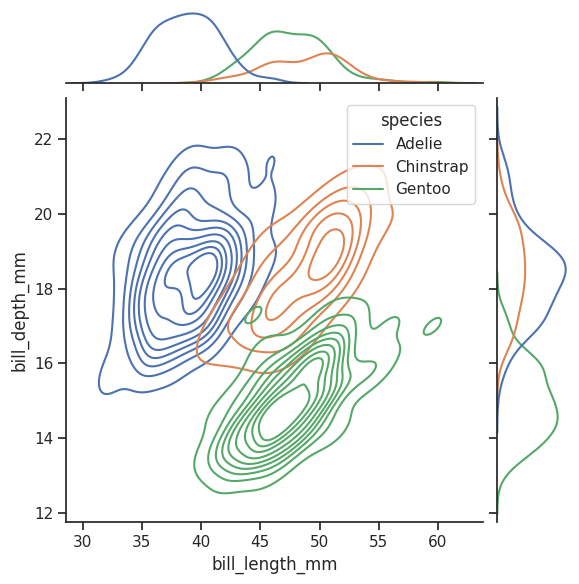

In [ ]:
import seaborn as sns
sns.set_theme(style="ticks")

# Load the penguins dataset
penguins = sns.load_dataset("penguins")
penguins.dropna(inplace=True)

# Show the joint distribution using kernel density estimation
g = sns.jointplot(
    data=penguins,
    x="bill_length_mm", y="bill_depth_mm", hue="species",
    kind="kde",
)

In [ ]:
df = penguins[['bill_length_mm', 'bill_depth_mm', 'species']].copy()
df.head()

,bill_length_mm,bill_depth_mm,species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
4,36.7,19.3,Adelie
5,39.3,20.6,Adelie


### **원본 데이터는 3개이나 Nan을 제거하면 3개의 Global Outlier?**

In [ ]:
# print("1. Gentoo 종 중 부리 길이가 매우 짧거나 깊이가 깊은 개체 (중앙 파란색 낙도)")
# df[(df['species'] == 'Adelie') & (df['bill_length_mm'] > 45) & (df['bill_depth_mm'] > 21)]

In [ ]:
print("2. Gentoo 종 중 부리 길이가 매우 짧거나 깊이가 깊은 개체 (중앙 초록색 낙도)")
df[(df['species'] == 'Gentoo') & (df['bill_length_mm'] < 45) & (df['bill_depth_mm'] > 17)]

2. Gentoo 종 중 부리 길이가 매우 짧거나 깊이가 깊은 개체 (중앙 초록색 낙도)


,bill_length_mm,bill_depth_mm,species
257,44.4,17.3,Gentoo


In [ ]:
print("3. Gentoo 종 중 부리 길이가 독보적으로 긴 개체 (오른쪽 초록색 낙도)")
penguins[(penguins['species'] == 'Gentoo') & (penguins['bill_length_mm'] > 59)]

3. Gentoo 종 중 부리 길이가 독보적으로 긴 개체 (오른쪽 초록색 낙도)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
253,Gentoo,Biscoe,59.6,17.0,230.0,6050.0,Male


KDE 플롯은 데이터가 몰려있는 곳은 촘촘한 등고선으로 그리지만, 주변에 동료가 없는 외로운 데이터는 마치 섬처럼 따로 떨어져서 표현됩니다.

**Adelie(파랑)** 의 경우 보통 부리 길이가 40mm 미만인데, 46mm인 개체가 하나 있어 저렇게 섬이 생겼습니다.

**Gentoo(초록)** 의 경우 59.6mm라는 압도적인 부리 길이를 가진 개체가 우측 하단에 별도의 섬을 만들었습니다.

## 변수가 아주 많아지면 시각화하여 찾기가 힘들다... 아래 알고리즘으로

## **1. 결합확률분포(Joint Distribution) 알고리즘으로 이상치 찾기**

Text(0.5, 0.98, 'Joint Plot of X and Y with Generated Outliers')

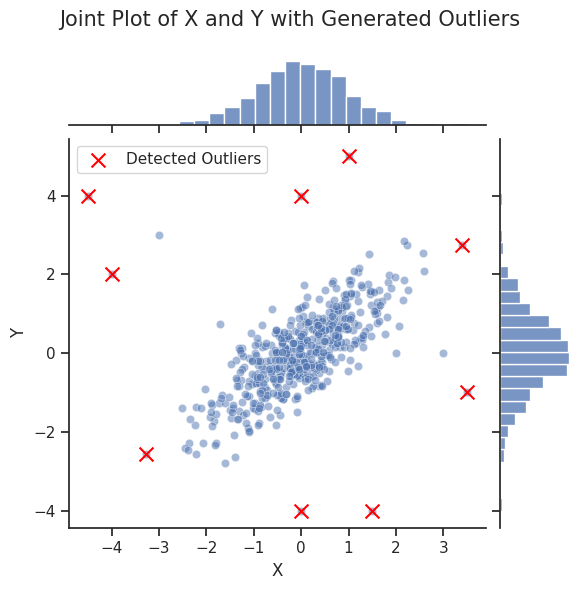

총 데이터 개수: 510
탐지된 이상치 개수: 9

[탐지된 이상치 데이터]
            X         Y
131  3.398876  2.750996
239 -3.274923 -2.566842
501  3.500000 -1.000000
503 -4.000000  2.000000
504 -4.500000  4.000000
506  1.000000  5.000000
507  0.000000 -4.000000
508  0.000000  4.000000
509  1.500000 -4.000000


In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 생성 (정상 데이터)
np.random.seed(42)

# 상관관계가 있는 두 변수 생성 (X, Y)
mean = [0, 0]
cov = [[1, 0.8], [0.8, 1]]  # 0.8의 강한 양의 상관관계
x_inliers, y_inliers = np.random.multivariate_normal(mean, cov, 500).T

# 2. 이상치 생성 및 추가
x_outliers = np.array([2, 3.5, 3, -4, -4.5, -3, 1, 0, 0, 1.5])
y_outliers = np.array([0, -1, 0, 2, 4, 3, 5, -4, 4, -4])

# 전체 데이터 통합 (변수명 d/df 대신 data 사용)
X = np.concatenate([x_inliers, x_outliers])
Y = np.concatenate([y_inliers, y_outliers])
data = pd.DataFrame({'X': X, 'Y': Y})

# 3. 데이터 분포 시각화 (Seaborn Jointplot)
jg = sns.jointplot(data=data, x='X', y='Y', kind='scatter', color='b', alpha=0.5)
plt.subplots_adjust(top=0.9)
jg.fig.suptitle('Joint Plot of X and Y with Generated Outliers', fontsize=15)

# 4. 이상치 탐지 (Z-score 사용)
# data 변수를 사용하여 Z-score 계산
z_scores_x = np.abs(stats.zscore(data['X']))
z_scores_y = np.abs(stats.zscore(data['Y']))

# X 또는 Y 중 하나라도 Z-score가 3을 넘으면 이상치로 정의
outlier_mask = (z_scores_x > 3) | (z_scores_y > 3)
detected_outliers = data[outlier_mask]

# 5. 탐지된 이상치 시각화에 표시 (빨간색 'X')
jg.ax_joint.scatter(detected_outliers['X'], detected_outliers['Y'],
                   color='red', marker='x', s=100, label='Detected Outliers')

# 범례 추가
jg.ax_joint.legend()

plt.show()

# 탐지된 결과 출력
print(f"총 데이터 개수: {len(data)}")
print(f"탐지된 이상치 개수: {len(detected_outliers)}")
print("\n[탐지된 이상치 데이터]")
print(detected_outliers)

Text(0.5, 0.98, 'Penguin Bill Dimensions: Outlier Detection')

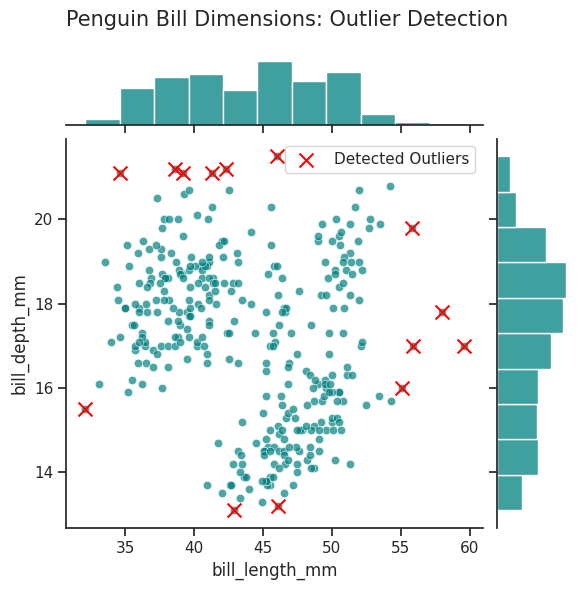

--- 탐지 결과 ---
     bill_length_mm  bill_depth_mm
13             38.6           21.2
14             34.6           21.1
19             46.0           21.5
35             39.2           21.1
49             42.3           21.2
61             41.3           21.1
142            32.1           15.5
169            58.0           17.8
215            55.8           19.8
220            46.1           13.2
244            42.9           13.1
253            59.6           17.0
321            55.9           17.0
335            55.1           16.0


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

data = df[['bill_length_mm', 'bill_depth_mm']]

# 2. 데이터 분포 시각화 (Seaborn Jointplot)
# X축: 부리 길이, Y축: 부리 깊이
jg = sns.jointplot(data=data, x='bill_length_mm', y='bill_depth_mm',
                   kind='scatter', color='teal', alpha=0.7)

plt.subplots_adjust(top=0.9)
jg.fig.suptitle('Penguin Bill Dimensions: Outlier Detection', fontsize=15)

# 3. 이상치 탐지 (Z-score 사용)
# 기준을 2.0으로 설정 (데이터 개수가 적을 때는 3.0보다 2.0이 적당할 수 있습니다)
z_threshold = 2.0
z_scores_x = np.abs(stats.zscore(data['bill_length_mm']))
z_scores_y = np.abs(stats.zscore(data['bill_depth_mm']))

# 어느 한쪽이라도 임계치를 넘으면 이상치로 판단
outlier_mask = (z_scores_x > z_threshold) | (z_scores_y > z_threshold)
detected_outliers = data[outlier_mask]

# 4. 탐지된 이상치 시각화에 표시 (빨간색 'X')
if not detected_outliers.empty:
    jg.ax_joint.scatter(detected_outliers['bill_length_mm'],
                       detected_outliers['bill_depth_mm'],
                       color='red', marker='x', s=100, label='Detected Outliers')
    jg.ax_joint.legend()

plt.show()

# 5. 결과 출력
print("--- 탐지 결과 ---")
if detected_outliers.empty:
    print("탐지된 이상치가 없습니다.")
else:
    print(detected_outliers)

Text(0.5, 0.98, 'Penguin Bill Dimensions: Outlier Detection by Species')

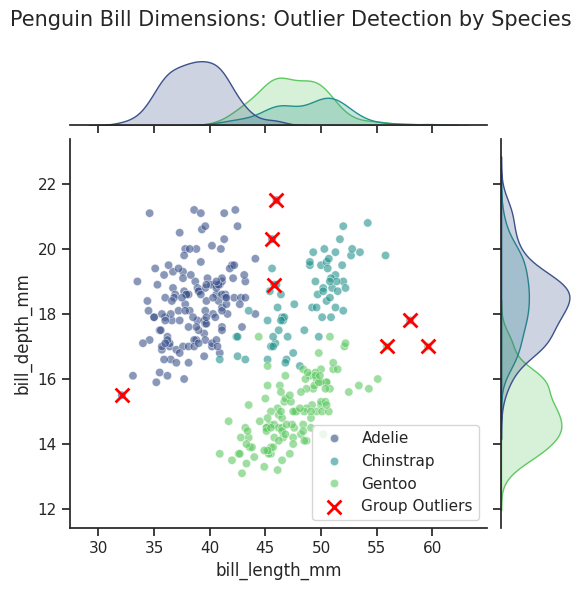

--- 종별 탐지 결과 ---
     bill_length_mm  bill_depth_mm    species
19             46.0           21.5     Adelie
73             45.8           18.9     Adelie
111            45.6           20.3     Adelie
142            32.1           15.5     Adelie
169            58.0           17.8  Chinstrap
253            59.6           17.0     Gentoo
321            55.9           17.0     Gentoo


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# 1. 데이터 준비 (species 포함)
# 원본 데이터프레임인 df에서 필요한 컬럼을 가져옵니다.
data = df[['bill_length_mm', 'bill_depth_mm', 'species']].dropna()

# 2. 종별 Z-score 계산을 위한 함수 정의
def get_group_outliers(group, threshold=2.0):
    z_x = np.abs(stats.zscore(group['bill_length_mm']))
    z_y = np.abs(stats.zscore(group['bill_depth_mm']))
    # 해당 그룹 내에서 임계값을 넘는 데이터 마스크 생성
    # numpy 배열 대신 pandas Series로 반환하여 인덱싱 문제 해결
    return pd.Series((z_x > threshold) | (z_y > threshold), index=group.index)

# 3. 종별로 그룹화하여 이상치 마스크 생성
# transform을 사용하여 원본 데이터와 인덱스가 일치하는 불리언 시리즈를 얻습니다.
outlier_mask = data.groupby('species', group_keys=False).apply(
    lambda x: get_group_outliers(x, threshold=2.5), include_groups=False
)
detected_outliers = data[outlier_mask]

# 4. 시각화 (Seaborn Jointplot 활용)
# hue='species'를 추가하여 종별로 색상을 다르게 표시합니다.
jg = sns.jointplot(data=data, x='bill_length_mm', y='bill_depth_mm',
                   hue='species', palette='viridis', alpha=0.6)

plt.subplots_adjust(top=0.9)
jg.fig.suptitle('Penguin Bill Dimensions: Outlier Detection by Species', fontsize=15)

# 5. 탐지된 이상치를 시각화에 표시 (종별 색상과 상관없이 빨간색 X로 강조)
if not detected_outliers.empty:
    jg.ax_joint.scatter(detected_outliers['bill_length_mm'],
                       detected_outliers['bill_depth_mm'],
                       color='red', marker='x', s=100,
                       linewidths=2, label='Group Outliers')
    jg.ax_joint.legend()

plt.show()

# 6. 결과 출력
print("--- 종별 탐지 결과 ---")
if detected_outliers.empty:
    print("탐지된 이상치가 없습니다.")
else:
    # 종별로 몇 개의 이상치가 나왔는지 확인
    print(detected_outliers.sort_values('species'))

## **2. [Nearest Neighbors](https://scikit-learn.org/stable/modules/neighbors.html) 알고리즘으로 이상치 찾기**

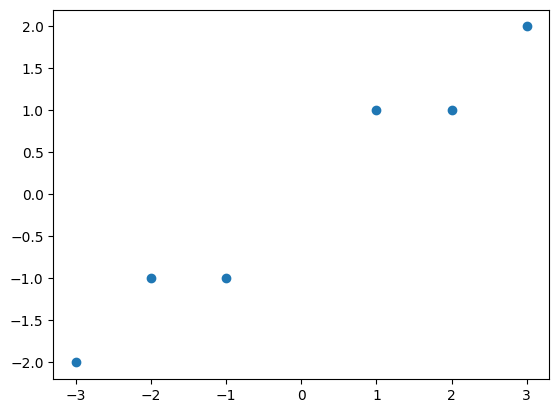

In [ ]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt
X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
nbrs = NearestNeighbors(n_neighbors=3, algorithm='ball_tree').fit(X)
distances, indices = nbrs.kneighbors(X)

indices    # 각 index별로 가장 가까운 점의 index
distances  # 최근접 포인트로 부터 L2(유클리디언 거리)
distances.mean(axis =1) # 최근접 이웃간의 평균 거리(L2)

array([1.07868933, 0.80473785, 1.21676051, 1.07868933, 0.80473785,
       1.21676051])

In [ ]:
nbrs.get_params()

{'algorithm': 'ball_tree',
 'leaf_size': 30,
 'metric': 'minkowski',
 'metric_params': None,
 'n_jobs': None,
 'n_neighbors': 3,
 'p': 2,
 'radius': 1.0}

In [ ]:
# 1. 알고리즘 호출
# nbrs = NearestNeighbors(n_neighbors=2, p=1, algorithm='ball_tree').fit(X)

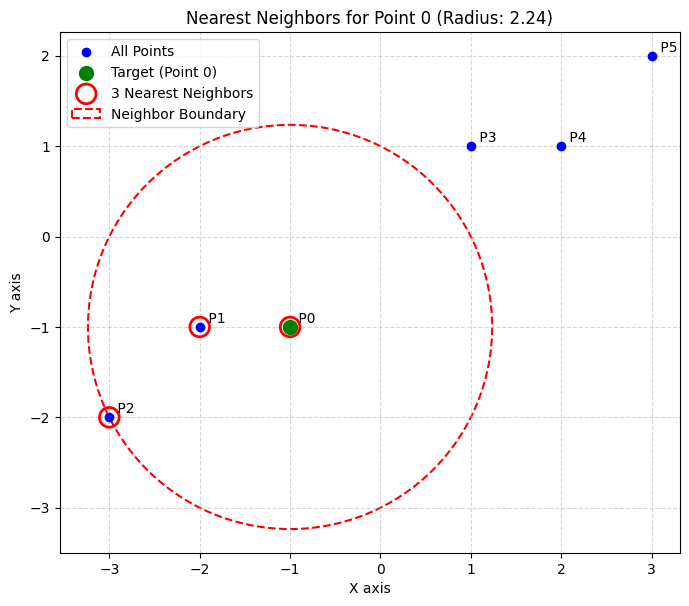

In [ ]:
# 2. 모델 학습
distances, indices = nbrs.kneighbors(X)

# 3. 시각화 설정
fig, ax = plt.subplots(figsize=(8, 8)) # 원이 찌그러지지 않게 정사각형 비율 권장

# 기준점 (Point 0) 설정
target_idx = 0
target_point = X[target_idx]

# Point 0의 이웃 정보 가져오기
neighbor_indices = indices[target_idx]
neighbor_distances = distances[target_idx]

# --- 시각화 요소 추가 ---

# [1] 모든 데이터 점 플롯 (파란색)
ax.scatter(X[:, 0], X[:, 1], color='blue', label='All Points', zorder=3)

# [2] 기준점 (Point 0) 강조 (초록색)
ax.scatter(target_point[0], target_point[1], color='green', s=100, label='Target (Point 0)', zorder=4)

# [3] 이웃 점들을 빨간색 테두리로 표시
ax.scatter(X[neighbor_indices, 0], X[neighbor_indices, 1],
           edgecolors='red', facecolors='none', s=200, linewidths=2,
           label='3 Nearest Neighbors', zorder=2)

# [4] **가장 먼 이웃까지의 거리를 반지름으로 하는 큰 원 그리기**
# distances는 정렬되어 있으므로, 마지막 원소[-1]가 가장 먼 이웃의 거리입니다.
max_distance = neighbor_distances[-1]

# 원 객체 생성 (중심: target_point, 반지름: max_distance)
circle = plt.Circle(target_point, max_distance, color='red', fill=False, linestyle='--', linewidth=1.5, label='Neighbor Boundary', zorder=1)
ax.add_patch(circle)


# --- 그래프 세부 설정 ---

# 축 라벨 및 타이틀
ax.set_title(f"Nearest Neighbors for Point 0 (Radius: {max_distance:.2f})")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")

# 점 번호 주석 달기
for i, txt in enumerate(range(len(X))):
    ax.annotate(f' P{i}', (X[i, 0], X[i, 1]), xytext=(3, 3), textcoords='offset points')

# 그래프 비율을 1:1로 맞춰서 원이 찌그러지지 않게 함
ax.set_aspect('equal', adjustable='box')

# 그리드 및 범례
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='upper left')

# 축 범위 자동 조절 (원이 잘리지 않게)
ax.autoscale_view()

plt.show()

NearestNeighbors(n_neighbors=6)

<Axes: >

Text(0.5, 1.0, 'Distance mean of KNN')

Text(0.5, 0, 'Instances')

Text(0, 0.5, 'Mean of Distance')

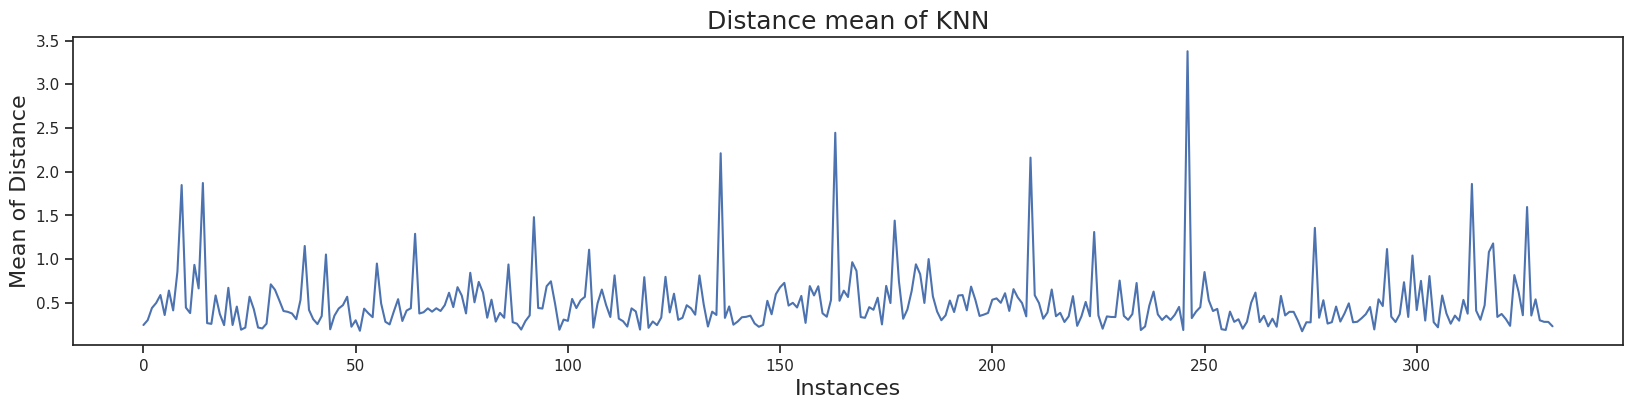

In [ ]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import pandas as pd

nbrs = NearestNeighbors(n_neighbors = 6) # 5,6,7,8 개
X = df[['bill_length_mm', 'bill_depth_mm']]

nbrs.fit(X)
distances, indices = nbrs.kneighbors(X) # distances : distances between data points
                                           # indices : associated index values

pd.Series(distances.mean(axis =1)).plot(figsize=(20,4))
plt.title('Distance mean of KNN', fontsize = 18)
plt.xlabel('Instances', fontsize = 16); plt.ylabel('Mean of Distance', fontsize = 16)

Spike 되는 instance는 anomaly이며, 평균 거리가 '2.0'이상이면 이상치라고 판단

In [ ]:
outlier_index = np.where(distances.mean(axis = 1) > 2)
df.iloc[outlier_index]

,bill_length_mm,bill_depth_mm,species
142,32.1,15.5,Adelie
169,58.0,17.8,Chinstrap
215,55.8,19.8,Chinstrap
253,59.6,17.0,Gentoo


## **3. [Outlier detection with Local Outlier Factor (LOF)](https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html) 알고리즘으로 이상치 찾기**

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_lof_outlier_detection_001.png">

In [ ]:
import numpy as np
from sklearn.neighbors import NearestNeighbors

# 예시 데이터 생성
X = np.array([[1, 1], [1, 2], [2, 1], [10, 10], [1, 1.1]])

In [ ]:
# 1. KNN 모델 설정 (k개의 이웃을 찾음)
nbrs = NearestNeighbors(n_neighbors=2).fit(X)
distances, indices = nbrs.kneighbors(X)
distances, indices

(array([[ 0.        ,  0.1       ],
        [ 0.        ,  0.9       ],
        [ 0.        ,  1.        ],
        [ 0.        , 12.04159458],
        [ 0.        ,  0.1       ]]),
 array([[0, 4],
        [1, 4],
        [2, 0],
        [3, 1],
        [4, 0]]))

In [ ]:
k_distances = distances[:, -1]
k_distances

array([ 0.1       ,  0.9       ,  1.        , 12.04159458,  0.1       ])

In [ ]:
# 3. Reachability Distance 계산
# 내 주변 이웃들(indices)이 각각 자신의 이웃을 찾았을 때의 k-distance 값들을 조회하는 인덱싱(Indexing) 기법
k_distances[indices]

array([[ 0.1       ,  0.1       ],
       [ 0.9       ,  0.1       ],
       [ 1.        ,  0.1       ],
       [12.04159458,  0.9       ],
       [ 0.1       ,  0.1       ]])

In [ ]:
# reach_dist(A, B) = max(k-dist(B), dist(A, B))
reach_dists = np.maximum(k_distances[indices], distances)
k_distances[indices]
print('\n')
distances
print('\n')
reach_dists

array([[ 0.1       ,  0.1       ],
       [ 0.9       ,  0.1       ],
       [ 1.        ,  0.1       ],
       [12.04159458,  0.9       ],
       [ 0.1       ,  0.1       ]])

array([[ 0.        ,  0.1       ],
       [ 0.        ,  0.9       ],
       [ 0.        ,  1.        ],
       [ 0.        , 12.04159458],
       [ 0.        ,  0.1       ]])

array([[ 0.1       ,  0.1       ],
       [ 0.9       ,  0.9       ],
       [ 1.        ,  1.        ],
       [12.04159458, 12.04159458],
       [ 0.1       ,  0.1       ]])

- 만약 0번 포인트의 인접한 이웃 2개가 [2, 5]번이라고 가정
- indices[0]은 [0, 2, 5] (자기 자신 포함)
- k_distances[indices[0]]은 [k-dist(0), k-dist(2), k-dist(5)]가 됩니다.
- LOF 알고리즘에서 Reachability Distance를 계산할 때, 단순히 내 거리만 보는 것이 아니라 내 이웃들이 가진 k-distance를 비교 대상으로 삼아야 하기 때문

In [ ]:
# 4. Local Reachability Density (LRD) 계산
# LRD = 1 / (평균 reach_dist)
lrd = 1 / (np.mean(reach_dists, axis=1) + 1e-10) # 0으로 나누기 방지
lrd

array([9.99999999, 1.11111111, 1.        , 0.08304548, 9.99999999])

In [ ]:
# 5. LOF 점수 계산
# LRD 계산
lrd = 1 / (np.mean(reach_dists, axis=1) + 1e-10) # 0으로 나누기 방지

# LOF = (이웃들의 LRD 평균) / (나의 LRD)
lof_scores = []
for i in range(len(X)):
    neighbor_indices = indices[i]
    lrd_neighbors = lrd[neighbor_indices]
    lof = np.mean(lrd_neighbors) / lrd[i]
    lof_scores.append(lof)

lof_scores

[np.float64(1.0),
 np.float64(4.999999996000047),
 np.float64(5.499999995500054),
 np.float64(7.189774765307968),
 np.float64(1.0)]

In [ ]:
df

,bill_length_mm,bill_depth_mm,species
0,39.1,18.7,Adelie
1,39.5,17.4,Adelie
2,40.3,18.0,Adelie
4,36.7,19.3,Adelie
5,39.3,20.6,Adelie
...,...,...,...
338,47.2,13.7,Gentoo
340,46.8,14.3,Gentoo
341,50.4,15.7,Gentoo
342,45.2,14.8,Gentoo


In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# 실제 모델 사용
clf = LocalOutlierFactor(n_neighbors=6)
X = df[['bill_length_mm', 'bill_depth_mm']]
# -1은 이상치, 1은 정상치
y_pred = clf.fit_predict(X)
y_pred

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1

In [ ]:
df[df.index == 257]

,bill_length_mm,bill_depth_mm,species
257,44.4,17.3,Gentoo


In [ ]:
df['outlier'] = y_pred
df[df['outlier'] == -1]

,bill_length_mm,bill_depth_mm,species,outlier
14,34.6,21.1,Adelie,-1
19,46.0,21.5,Adelie,-1
70,33.5,19.0,Adelie,-1
98,33.1,16.1,Adelie,-1
101,41.0,20.0,Adelie,-1
124,35.2,15.9,Adelie,-1
142,32.1,15.5,Adelie,-1
183,54.2,20.8,Chinstrap,-1
215,55.8,19.8,Chinstrap,-1
220,46.1,13.2,Gentoo,-1


### 253번은 outlier로 감지가 어렵다

### K-neighbors를 Hyperparameter tuning

In [ ]:
from sklearn.neighbors import LocalOutlierFactor

# Define a range for n_neighbors to tune
n_neighbors_range = range(5, 21) # From 5 to 20

# Target indices to check
target_indices = [253, 257]

print(f"Checking if indices {target_indices} are identified as outliers for different n_neighbors values:")
print("----------------------------------------------------------------------------------------")

for n_neighbors_val in n_neighbors_range:
    clf = LocalOutlierFactor(n_neighbors=n_neighbors_val,
                             contamination=0.01)

    y_pred = clf.fit_predict(df[['bill_length_mm', 'bill_depth_mm']])

    # Create a temporary DataFrame to easily filter by outlier status and index
    temp_df = df.copy()
    temp_df['outlier'] = y_pred

    outliers_df = temp_df[temp_df['outlier'] == -1]

    found_indices = []
    for idx in target_indices:
        if idx in outliers_df.index:
            found_indices.append(idx)

    if len(found_indices) == len(target_indices):
        print(f"n_neighbors = {n_neighbors_val}: ALL target indices {target_indices} are outliers.")
    elif len(found_indices) > 0:
        print(f"n_neighbors = {n_neighbors_val}: Some target indices {found_indices} are outliers.")
    else:
        print(f"n_neighbors = {n_neighbors_val}: None of the target indices {target_indices} are outliers.")


Checking if indices [253, 257] are identified as outliers for different n_neighbors values:
----------------------------------------------------------------------------------------
n_neighbors = 5: None of the target indices [253, 257] are outliers.
n_neighbors = 6: None of the target indices [253, 257] are outliers.
n_neighbors = 7: None of the target indices [253, 257] are outliers.
n_neighbors = 8: None of the target indices [253, 257] are outliers.
n_neighbors = 9: Some target indices [253] are outliers.
n_neighbors = 10: Some target indices [253] are outliers.
n_neighbors = 11: Some target indices [253] are outliers.
n_neighbors = 12: Some target indices [253] are outliers.
n_neighbors = 13: Some target indices [253] are outliers.
n_neighbors = 14: Some target indices [253] are outliers.
n_neighbors = 15: Some target indices [253] are outliers.
n_neighbors = 16: Some target indices [253] are outliers.
n_neighbors = 17: Some target indices [253] are outliers.
n_neighbors = 18: Some

## **4. [IsolationForest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.IsolationForest.html) 알고리즘으로 이상치 찾기**

In [ ]:
from sklearn.ensemble import IsolationForest

# 2. 모델 생성
# contamination: 데이터셋에 포함된 이상치의 비율(예: 0.05)
model = IsolationForest(n_estimators=100,
                        contamination=0.01,
                        random_state=42)

# 3. 모델 학습 및 예측
# 결과: 1(정상), -1(이상치)
y_pred = model.fit_predict(X)

print("예측 결과:", y_pred)

예측 결과: [ 1  1  1  1  1  1  1  1  1 -1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1  1  1  1  1  1  1  

In [ ]:
df['outlier'] = y_pred
df[df['outlier'] == -1]

,bill_length_mm,bill_depth_mm,species,outlier
14,34.6,21.1,Adelie,-1
19,46.0,21.5,Adelie,-1
142,32.1,15.5,Adelie,-1
253,59.6,17.0,Gentoo,-1


## **5. Autoendocer 딥러닝 알고리즘으로 이상치 찾기**

In [ ]:
# 개념적 워크플로우 (Keras 예시)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from sklearn.preprocessing import StandardScaler

penguins = sns.load_dataset("penguins")
penguins.dropna(inplace=True)
data = penguins[['bill_length_mm', 'bill_depth_mm']]

# StandardScaler 객체 생성
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data) # data_encoded를 입력


# 1. 모델 구조 (입력 2개 -> 압축 1개 -> 출력 2개)
input_dim = 2 # bill_length, bill_depth
input_layer = Input(shape=(input_dim,))
encoded = Dense(1, activation='relu')(input_layer) # 압축(Bottleneck)
decoded = Dense(input_dim, activation='linear')(encoded) # 복원

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# 2. 정상 데이터로만 학습 (Novelty Detection 방식일 때 유리)
autoencoder.fit(data_scaled, data_scaled, epochs=50, batch_size=16, verbose=0)

# 3. 재구성 오차 계산
predictions = autoencoder.predict(data_scaled)
mse = np.mean(np.power(data_scaled - predictions, 2), axis=1)

# 4. 오차가 큰 상위 n%를 이상치로 판단
threshold = np.percentile(mse, 98)
is_outlier = mse > threshold
data[is_outlier]

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


,bill_length_mm,bill_depth_mm
98,33.1,16.1
142,32.1,15.5
169,58.0,17.8
183,54.2,20.8
215,55.8,19.8
253,59.6,17.0
321,55.9,17.0
